In [101]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from scipy.sparse import linalg
import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.providers.fake_provider import GenericBackendV2

### __INISIALISASI__ ###

In [102]:
#membuat list untuk 17 panjang ikatan untuk moelkul hidrogen
bond_lengths = np.array([
    #repulsive region
    0.5, 0.6, 0.65, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.85, 0.9, 0.95,
    #region dari thesis
    1.0, 1.2, 1.3, 1.39, 1.4, 1.4011, 1.41, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2])

#membuat array kosong untuk menyimpan energi ground state hasil simulasi pada panjang ikatan yg berbeda
energies_exact = []
energies_sv = []
energies_aer = []
energies_hw = []

In [103]:
results = []

for bond_length in bond_lengths:
    #update PySCFDriver dengan panjang ikatan dinamis
    driver = PySCFDriver(
        atom=f"H 0 0 0; H 0 0 {bond_length}",  # ← PERUBAHAN DI SINI
        unit=DistanceUnit.ANGSTROM,
        basis="sto3g",
    )
    problem        = driver.run()
    mapper         = ParityMapper(num_particles=problem.num_particles)
    qubit_op       = mapper.map(problem.hamiltonian.second_q_op())
    num_particles  = problem.num_particles
    num_spatial    = problem.num_spatial_orbitals
    #print(f"Jumlah qubit sekarang: {qubit_op.num_qubits}") 

    nuclear_rep = problem.hamiltonian.nuclear_repulsion_energy

    #referensi klasik
    ref_result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    E_exact    = ref_result.eigenvalue.real + nuclear_rep
    #print(f"E_exact (FCI/NumPy): {E_exact:.6f} Ha")

    #fungsi pembantu: buat ansatz UCCSD + HF init
    n_qubits = qubit_op.num_qubits
    def build_ansatz():
        hf = HartreeFock(
            num_spatial_orbitals = problem.num_spatial_orbitals,
            num_particles        = problem.num_particles,
            qubit_mapper         = mapper,
        )
        return UCCSD(
            num_spatial_orbitals = problem.num_spatial_orbitals,
            num_particles        = problem.num_particles,
            qubit_mapper         = mapper,
            initial_state        = hf,
        )
    
    #optimizer 
    def make_callback(history):
        def cb(eval_count, params, energy, std):
            history.append(energy)
            #print(f"  iter {eval_count:3d} | E = {energy:.6f} Ha")
        return cb
    
    #STATE VECTOR UNTUK WARM STARTING POINT
    ansatz_sv   = build_ansatz()
    history_sv  = []
 
    vqe_sv = VQE(
        estimator    = StatevectorEstimator(),
        ansatz       = ansatz_sv,
        optimizer    = SLSQP(maxiter=300),
        initial_point= np.zeros(ansatz_sv.num_parameters),
        callback     = make_callback(history_sv),
    )
    result_sv = vqe_sv.compute_minimum_eigenvalue(qubit_op)

    #VQE AER SIMULATOR DENGAN NOISE MODEL
    noise_model  = NoiseModel()
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(0.001, 1), ["u1", "u2", "u3", "rz", "sx", "x"]
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(0.005, 2), ["cx","ecr"]
    )
    #transpalasi
    fake_backend = GenericBackendV2(num_qubits=4, seed=42)
    #backend = AerSimulator(noise_model=noise_model)
    pm = generate_preset_pass_manager(
        optimization_level=3,
        backend=fake_backend
    )

    ansatz_aer   = build_ansatz()
    ansatz_aer_t = pm.run(ansatz_aer)
    qubit_op_t    = qubit_op.apply_layout(ansatz_aer_t.layout)

    noisy_estimator = AerEstimator(
        options={"backend_options": {"noise_model": noise_model}, 
                "run_options": {"shots": 32768}
            }
    )

    history_aer  = []

    optimal_theta = result_sv.optimal_point
    vqe_aer = VQE(
        estimator    = noisy_estimator,
        ansatz       = ansatz_aer_t,
        optimizer    = COBYLA(maxiter=500),
        initial_point= optimal_theta,  #pakai hasil statevector sebagai titik awal
        callback     = make_callback(history_aer),
    )
    
    result_aer = vqe_aer.compute_minimum_eigenvalue(qubit_op)
    E_aer      = result_aer.eigenvalue.real + nuclear_rep
    results.append({
        'bond_length': bond_length,
        'E_exact': E_exact,
        'E_vqe': E_aer,
        'iterations': len(history_aer)
    })
    #print(f"{bond_length*2:<18.4f} {E_exact:<18.6f} {E_sv:<18.6f} {len(history_sv):<12}")

In [104]:
import pandas as pd

df = pd.DataFrame(results)
print(df.to_string(index=False))

 bond_length   E_exact     E_vqe  iterations
      0.5000 -1.055160 -1.020089          33
      0.6000 -1.116286 -1.086449          34
      0.6500 -1.129905 -1.102316          34
      0.7000 -1.136189 -1.110625          34
      0.7200 -1.137112 -1.112298          34
      0.7400 -1.137284 -1.113189          34
      0.7600 -1.136796 -1.113390          36
      0.7800 -1.135727 -1.112982          38
      0.8000 -1.134148 -1.112035          34
      0.8500 -1.128362 -1.107719          36
      0.9000 -1.120560 -1.101242          35
      0.9500 -1.111339 -1.093216          36
      1.0000 -1.101150 -1.084108          36
      1.2000 -1.056741 -1.043077          43
      1.3000 -1.035186 -1.022742          35
      1.3900 -1.017339 -1.005769          39
      1.4000 -1.015468 -1.003983          37
      1.4011 -1.015264 -1.003788          34
      1.4100 -1.013622 -1.002220          39
      1.5000 -0.998149 -0.987398          36
      1.6000 -0.983473 -0.973261          34
      1.80

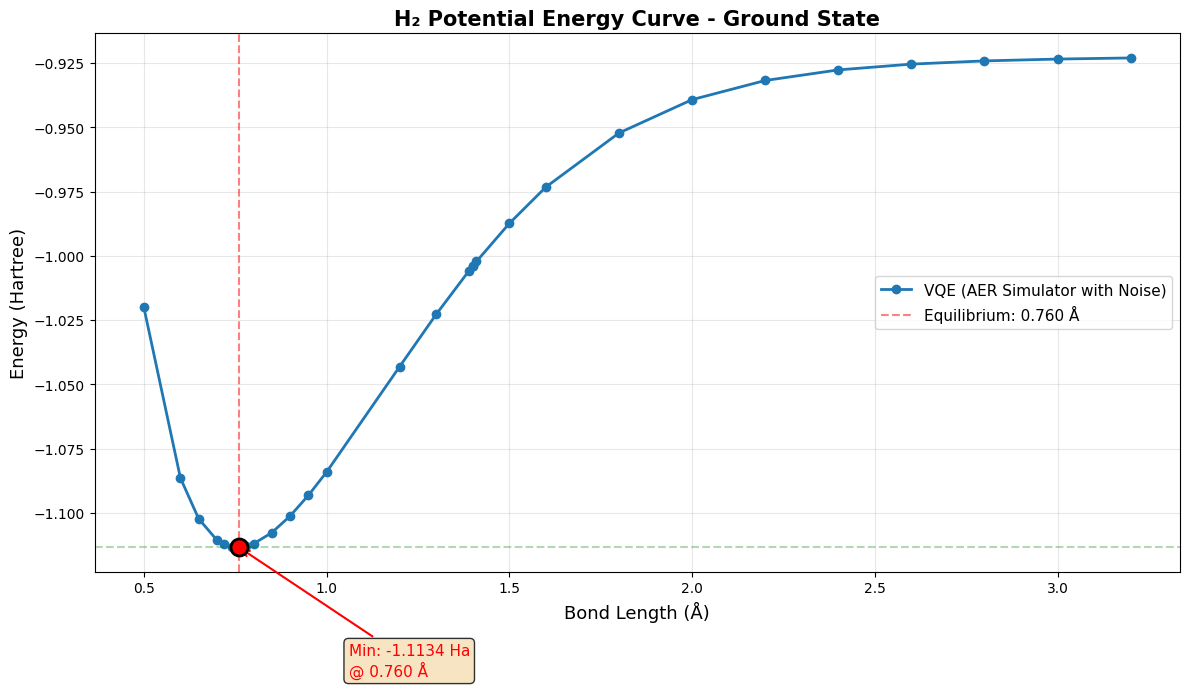


Equilibrium bond length: 0.7600 Å
Minimum energy (ground state): -1.113390 Ha


In [105]:
bond_lengths_plot = np.array([r['bond_length'] for r in results])
energies = np.array([r['E_vqe'] for r in results])

min_idx = np.argmin(energies)
min_bond = bond_lengths_plot[min_idx]
min_energy = energies[min_idx]

plt.figure(figsize=(12, 7))
plt.plot(bond_lengths_plot, energies, 'o-', linewidth=2, 
         markersize=6, label='VQE (AER Simulator with Noise)')

# Mark minimum dengan garis vertikal dan horizontal
plt.axvline(min_bond, color='red', linestyle='--', alpha=0.5, 
            label=f'Equilibrium: {min_bond:.3f} Å')
plt.axhline(min_energy, color='green', linestyle='--', alpha=0.3)

# Annotate minimum point
plt.scatter([min_bond], [min_energy], color='red', s=150, 
            zorder=5, edgecolor='black', linewidth=2)
plt.annotate(f'Min: {min_energy:.4f} Ha\n@ {min_bond:.3f} Å',
             xy=(min_bond, min_energy),
             xytext=(min_bond + 0.3, min_energy - 0.05),
             fontsize=11, color='red',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.xlabel('Bond Length (Å)', fontsize=13)
plt.ylabel('Energy (Hartree)', fontsize=13)
plt.title('H₂ Potential Energy Curve - Ground State', fontsize=15, weight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"Equilibrium bond length: {min_bond:.4f} Å")
print(f"Minimum energy (ground state): {min_energy:.6f} Ha")
print(f"{'='*50}")